# Gradients and Maxima / Minima

A guided notebook transcribed and expanded from the Coursera
*Calculus for Machine Learning and Data Science* lecture
*"Gradients and maxima/minima"* (Week 2 — Gradients and Gradient Descent).

This notebook explains:

- how the **gradient** finds minima/maxima of multivariable functions, just as the
  derivative does in 1D
- why at a min/max the **tangent plane is parallel to the floor** — every partial
  derivative is $0$
- the rule: **set $\nabla f = 0$ and solve the system**
- the worked example $f(x,y)=x^2+y^2 \Rightarrow (0,0)$
- generalization to many variables, with SymPy solving and visualizations

This notebook follows the repository `GUIDELINES.md` template and continues directly
from *Gradients*.

## 1. Introduction

> *"The gradient is pretty useful to minimize functions of two or more variables in the
> same way as the derivative was useful to minimize functions of one variable."*

In 1D we find a minimum by setting the **slope** (derivative) to zero. In higher
dimensions we do the same thing with **every** partial derivative at once — i.e. we set
the **gradient** to the zero vector.

After this notebook you will be able to:

- explain why minima/maxima occur where the gradient is zero
- find candidate min/max points by solving $\nabla f = 0$
- carry this out by hand and with SymPy

## 2. Recap in one variable

For $f(x) = x^2$, the minimum is where the slope is $0$:

$$
f'(x) = 2x = 0 \quad\Rightarrow\quad x = 0 .
$$

So the minimum sits at $x = 0$.

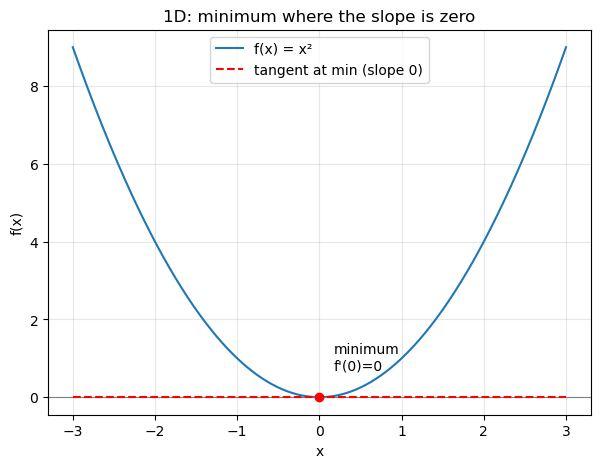

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

x = np.linspace(-3, 3, 400)
plt.figure(figsize=(7, 5))
plt.plot(x, x**2, label="f(x) = x²")
plt.axhline(0, color="gray", linewidth=0.8)
plt.plot(0, 0, "ro")
plt.annotate("minimum\nf'(0)=0", (0, 0), textcoords="offset points", xytext=(10, 20))
# flat tangent at the minimum
plt.plot(x, 0*x, "r--", label="tangent at min (slope 0)")
plt.title("1D: minimum where the slope is zero")
plt.xlabel("x"); plt.ylabel("f(x)")
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 3. Two variables: the tangent plane goes flat

Now take $f(x,y) = x^2 + y^2$. At its minimum:

> *"Notice that the tangent plane is actually parallel to the floor — and that's going to
> happen in every local minimum and maximum."*

Since the tangent plane is spanned by the two partial-derivative tangent lines, "parallel
to the floor" means **both** of those slopes are zero:

$$
\frac{\partial f}{\partial x} = 0 \qquad\text{and}\qquad \frac{\partial f}{\partial y} = 0 .
$$

> *"If you have a function of 12 variables, then you just need all 12 slopes — those of
> all the partial derivatives — to be 0."*

In gradient notation, a minimum or maximum requires

$$
\boxed{\;\nabla f = \mathbf{0}\;}
$$

## 4. Worked example: $f(x,y) = x^2 + y^2$

The partial derivatives are

$$
\frac{\partial f}{\partial x} = 2x, \qquad \frac{\partial f}{\partial y} = 2y .
$$

Set both to zero and solve the system:

$$
2x = 0, \quad 2y = 0 \quad\Rightarrow\quad (x, y) = (0, 0).
$$

So the minimum is at the origin $(0,0)$ — exactly the bottom of the bowl.

## 5. Solving $\nabla f = 0$ with SymPy

In [2]:
x, y = sp.symbols('x y')
f = x**2 + y**2

fx = sp.diff(f, x)
fy = sp.diff(f, y)
print("∇f = (", fx, ",", fy, ")")

critical = sp.solve([fx, fy], [x, y], dict=True)
print("Solve ∇f = 0  ->  critical point(s):", critical)

∇f = ( 2*x , 2*y )
Solve ∇f = 0  ->  critical point(s): [{x: 0, y: 0}]


### A function of more variables

The recipe is identical: set **every** partial derivative to zero and solve the system.

In [3]:
x1, x2, x3 = sp.symbols('x1 x2 x3')
g = (x1 - 1)**2 + (x2 + 2)**2 + (x3 - 3)**2   # bowl centered at (1, -2, 3)

grad = [sp.diff(g, v) for v in (x1, x2, x3)]
print("∇g =", tuple(grad))
print("critical point:", sp.solve(grad, [x1, x2, x3], dict=True))

∇g = (2*x1 - 2, 2*x2 + 4, 2*x3 - 6)
critical point: [{x1: 1, x2: -2, x3: 3}]


## 6. Visualizing the 2D minimum

The surface $z = x^2 + y^2$ is a bowl with its minimum at the origin. On the contour plot
the gradient field vanishes (arrows shrink to nothing) exactly at $(0,0)$.

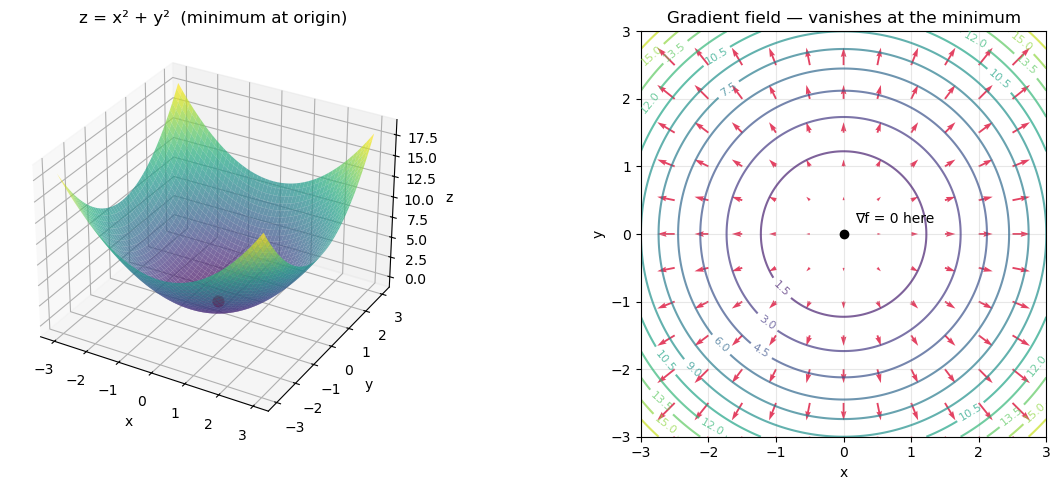

In [4]:
gx = np.linspace(-3, 3, 200)
gy = np.linspace(-3, 3, 200)
X, Y = np.meshgrid(gx, gy)
Z = X**2 + Y**2

fig = plt.figure(figsize=(13, 5))

ax = fig.add_subplot(1, 2, 1, projection="3d")
ax.plot_surface(X, Y, Z, cmap="viridis", alpha=0.7)
ax.scatter([0], [0], [0], color="red", s=60)
ax.set_title("z = x² + y²  (minimum at origin)")
ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("z")

qx = np.linspace(-3, 3, 13); qy = np.linspace(-3, 3, 13)
QX, QY = np.meshgrid(qx, qy)
ax2 = fig.add_subplot(1, 2, 2)
cs = ax2.contour(X, Y, Z, levels=12, cmap="viridis", alpha=0.7)
ax2.clabel(cs, inline=True, fontsize=8)
ax2.quiver(QX, QY, 2*QX, 2*QY, color="crimson", alpha=0.8)
ax2.plot(0, 0, "ko")
ax2.annotate("∇f = 0 here", (0, 0), textcoords="offset points", xytext=(8, 8))
ax2.set_title("Gradient field — vanishes at the minimum")
ax2.set_xlabel("x"); ax2.set_ylabel("y")
ax2.set_aspect("equal"); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. A note: critical points can be min, max, or saddle

Setting $\nabla f = 0$ finds **critical points** — candidate locations for a minimum or
maximum. They might also be a *maximum* (e.g. $f = -x^2 - y^2$) or a *saddle*
(e.g. $f = x^2 - y^2$). Telling them apart uses second derivatives (the **Hessian**),
covered in a later lecture. Here we focus on the first step: locating where the gradient
is zero.

In [5]:
x, y = sp.symbols('x y')
for expr, kind in [(x**2 + y**2, "minimum"),
                   (-x**2 - y**2, "maximum"),
                   (x**2 - y**2, "saddle")]:
    grad = [sp.diff(expr, v) for v in (x, y)]
    sols = sp.solve(grad, [x, y], dict=True)
    print(f"f = {str(expr):12}  ∇f = {tuple(grad)}  -> critical {sols}   ({kind})")

f = x**2 + y**2   ∇f = (2*x, 2*y)  -> critical [{x: 0, y: 0}]   (minimum)
f = -x**2 - y**2  ∇f = (-2*x, -2*y)  -> critical [{x: 0, y: 0}]   (maximum)
f = x**2 - y**2   ∇f = (2*x, -2*y)  -> critical [{x: 0, y: 0}]   (saddle)


## 8. Exercises

### Basic
1. State the condition (in words and in symbols) for $(x_0, y_0)$ to be a min/max of $f$.
2. For $f(x,y)=x^2+y^2$, find the critical point by solving $\nabla f = 0$.

### Intermediate
3. Find the critical point of $f(x,y) = (x-2)^2 + (y+1)^2$.
4. Find the critical point(s) of $f(x,y) = x^2 + y^2 - 4x - 6y + 13$.

### Advanced
5. Find all critical points of $f(x,y) = x^3 - 3x + y^2$ (there is more than one).
6. Find the critical point of $g(x,y,z) = x^2 + y^2 + z^2 - 2x + 4y$.

## 9. Solutions / Checks

In [6]:
x, y, z = sp.symbols('x y z')

def critical_points(expr, vars):
    grad = [sp.diff(expr, v) for v in vars]
    return grad, sp.solve(grad, list(vars), dict=True)

f = x**2 + y**2
print("2.", critical_points(f, (x, y))[1])

f3 = (x - 2)**2 + (y + 1)**2
print("3.", critical_points(f3, (x, y))[1])

f4 = x**2 + y**2 - 4*x - 6*y + 13
print("4.", critical_points(f4, (x, y))[1])

f5 = x**3 - 3*x + y**2
print("5.", critical_points(f5, (x, y))[1])

g = x**2 + y**2 + z**2 - 2*x + 4*y
print("6.", critical_points(g, (x, y, z))[1])

2. [{x: 0, y: 0}]
3. [{x: 2, y: -1}]
4. [{x: 2, y: 3}]
5. [{x: -1, y: 0}, {x: 1, y: 0}]
6. [{x: 1, y: -2, z: 0}]


## 10. Conclusion

- To minimize/maximize a multivariable function, do the higher-dimensional version of
  "set the slope to zero": **set every partial derivative to zero**, i.e.

$$
\nabla f = \mathbf{0}.
$$

- Geometrically this is where the **tangent plane is parallel to the floor**.
- For $f(x,y)=x^2+y^2$ the only solution is the minimum at $(0,0)$.
- Solving $\nabla f = 0$ gives **critical points**; classifying them as min, max, or
  saddle uses the **Hessian** (a later lecture).
- When the system is hard to solve directly, we approximate the minimum iteratively with
  **gradient descent** — the next topic.

## Appendix — Source transcript

Transcribed from the Coursera interactive transcript of
*"Gradients and maxima/minima"*
(*Calculus for Machine Learning and Data Science*, Week 2), read via the
Claude-for-Chrome browser extension. Key spoken points, lightly cleaned:

> The gradient minimizes functions of two-or-more variables the way the derivative does
> in one variable. For $f(x)=x^2$ the minimum is where the slope is $0$: $2x=0$ gives
> $x=0$. For $f(x,y)=x^2+y^2$ the minimum is where the tangent plane is parallel to the
> floor, which means both partial-derivative tangent lines have slope $0$. So set
> $\partial f/\partial x = 2x = 0$ and $\partial f/\partial y = 2y = 0$, giving
> $(x,y)=(0,0)$. With many variables (say 12) you need all the partial derivatives to be
> $0$. In short, to find minima and maxima, set all the partial derivatives to $0$ and
> solve that system of equations.